In [4]:
import torch
from torch.utils.data import Dataset, DataLoader, random_split, Subset
import torch.nn as nn
from torchvision.models import efficientnet_b0
import torchaudio
import torchaudio.transforms as T
import pandas as pd
import soundfile as sf
import math
from pathlib import Path
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from datetime import datetime
import mlflow
from torch.cuda.amp import autocast, GradScaler # to be used cast forward to float(16) improve training rates

In [5]:
files = Path('../data/train_audio').rglob('*.ogg')
train_df = pd.read_csv('../data/train.csv')
taxonomy_df = pd.read_csv('../data/taxonomy.csv')

In [6]:
# taxonomy_set is sorted in ascending order as a baseline for audios in
# train_audio, train_sounscrapes, and test_soundscrapes 
taxonomy_set = sorted(set((taxonomy_df['primary_label'].unique())))
label2idx = {label: idx for idx, label in enumerate(taxonomy_set)}
print(label2idx)

{'1161364': 0, '116570': 1, '1176823': 2, '1491113': 3, '1595929': 4, '209233': 5, '22930': 6, '22956': 7, '22961': 8, '22967': 9, '22973': 10, '22983': 11, '22985': 12, '23150': 13, '23154': 14, '23158': 15, '23176': 16, '23724': 17, '24279': 18, '24285': 19, '24287': 20, '24321': 21, '244024': 22, '25073': 23, '25092': 24, '25214': 25, '326272': 26, '41970': 27, '43435': 28, '47144': 29, '47158son01': 30, '47158son02': 31, '47158son03': 32, '47158son04': 33, '47158son05': 34, '47158son06': 35, '47158son07': 36, '47158son08': 37, '47158son09': 38, '47158son10': 39, '47158son11': 40, '47158son12': 41, '47158son13': 42, '47158son14': 43, '47158son15': 44, '47158son16': 45, '47158son17': 46, '47158son18': 47, '47158son19': 48, '47158son20': 49, '47158son21': 50, '47158son22': 51, '47158son23': 52, '47158son24': 53, '47158son25': 54, '476521': 55, '516975': 56, '517063': 57, '555123': 58, '555145': 59, '555146': 60, '64898': 61, '65377': 62, '65380': 63, '66971': 64, '67107': 65, '67252':

### Chunking the long files


In [7]:
train_df = train_df[['primary_label', 'filename']] # remove other columns for faster processing
train_df['file_path'] = '../data/train_audio/' + train_df['filename']
FIXED_LENGTH = 5 # the duration of a standard audio in seconds
def get_chunks_number(file_path:str):
    '''
    returns the number of chunks
    for the file in row idx of train_df
    '''
    return math.ceil(sf.info(file_path).duration/FIXED_LENGTH) # math.ceil to make sure 18.024 -> 4 chunnks, 15 -> 3 chunks
# add new rows for the new chunks separated from long files
new_idx = train_df.index.repeat(train_df['file_path'].apply(get_chunks_number)) 
train_df = train_df.loc[new_idx].reset_index(drop=True)
# add new offsets (offseting from the begining of long files) in seconds  
train_df['offset_sec'] = train_df.groupby('file_path').cumcount()*FIXED_LENGTH
# plan to use Efficientnet model, which requires labels are encoded in number
train_df['encoded_label'] = train_df['primary_label'].map(label2idx)
train_df.head(10) 


,primary_label,filename,file_path,offset_sec,encoded_label
0,1161364,1161364/iNat1216197.ogg,../data/train_audio/1161364/iNat1216197.ogg,0,0
1,1161364,1161364/iNat1216197.ogg,../data/train_audio/1161364/iNat1216197.ogg,5,0
2,1161364,1161364/iNat1216197.ogg,../data/train_audio/1161364/iNat1216197.ogg,10,0
3,1161364,1161364/iNat1216197.ogg,../data/train_audio/1161364/iNat1216197.ogg,15,0
4,1161364,1161364/iNat1114648.ogg,../data/train_audio/1161364/iNat1114648.ogg,0,0
5,1161364,1161364/iNat1114648.ogg,../data/train_audio/1161364/iNat1114648.ogg,5,0
6,1161364,1161364/iNat1114648.ogg,../data/train_audio/1161364/iNat1114648.ogg,10,0
7,1161364,1161364/iNat1114648.ogg,../data/train_audio/1161364/iNat1114648.ogg,15,0
8,1161364,1161364/iNat1114648.ogg,../data/train_audio/1161364/iNat1114648.ogg,20,0
9,1161364,1161364/iNat1114648.ogg,../data/train_audio/1161364/iNat1114648.ogg,25,0


## Prepare the dataset

In [8]:
SAMPLE_RATE = sf.info(train_df['file_path'][0]).samplerate
N_FFT = 1024
HOP_LENGTH = 512
F_MIN = 500
F_MAX = 16000
N_MELS = 128
WINDOW_FUNCTION = torch.hamming_window # hamming the edge of the windows to 0 to reduce abrupt change
TARGET_LENGTH = FIXED_LENGTH * SAMPLE_RATE
NUM_CLASSES = len(taxonomy_set) # take taxonomy set as a baseline

transform = T.MelSpectrogram(
    sample_rate=SAMPLE_RATE,
    n_fft=N_FFT,
    f_min=F_MIN,
    f_max=F_MAX,
    hop_length=HOP_LENGTH,
    n_mels=N_MELS,
    window_fn=WINDOW_FUNCTION 
)
class BirdSoundDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df
        self.transform = transform
        self.to_db = T.AmplitudeToDB()
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        file_path = row['file_path']
        waveform, _ = torchaudio.load(
            file_path,
            frame_offset=int(row['offset_sec']) * SAMPLE_RATE,
            num_frames=TARGET_LENGTH
            )
        if waveform.shape[0] > 1:                          # stereo → mono, safe-guarding in case there are 2 channels
            waveform = waveform.mean(dim=0, keepdim=True)
        if waveform.shape[1] < TARGET_LENGTH:
            padding = TARGET_LENGTH - waveform.shape[1]
            waveform = nn.functional.pad(waveform, (0, padding))
        if self.transform:
            waveform = self.transform(waveform)
        waveform = self.to_db(waveform)
        
        waveform = waveform.repeat(3,1,1) # -> (3, 128, time) to be able to fit into the efficient_net0
        return waveform, torch.tensor(row['encoded_label'],dtype=torch.long)
    
bird_dataset = BirdSoundDataset(train_df, transform)


### Training the EfficientNet_b0 model on the melspectrograms

In [9]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
save_folder_path = '../models/'
dataset = Subset(bird_dataset, range(1000))



In [10]:
def evaluate_model(model, criterion, test_loader) -> float:
    model.eval()
    eval_loss = 0
    with torch.no_grad():
        for mels, labels in tqdm(test_loader, desc=f'Evaluating the model ...'):
            mels, labels = mels.to(device), labels.to(device)
            preds = model(mels)
            eval_loss += criterion(preds, labels).item()

    print(f'Average Loss on the test datase: {eval_loss/len(test_loader)}')
    return eval_loss/len(test_loader)

In [11]:
def train_model(model, dataset, num_epochs):
    LEARNING_RATE = 1e-4
    BATCH_SIZE = 32
    MODEL_NAME = 'efficientnet_b0'
    train_dataset, val_dataset, test_dataset = random_split(dataset, [0.8, 0.1, 0.1])
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=4)
    val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=4)
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=4)    
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
    criterion = nn.CrossEntropyLoss()
    subfolder = Path('../models') / datetime.now().strftime("%Y%m%d_%m%s")
    subfolder.mkdir(parents=True, exist_ok=True)
    mlflow.set_experiment('BirdCLEF2026')
    with mlflow.start_run():
        # Log hyperparameters
        mlflow.log_params({
            'lr': LEARNING_RATE,
            'batch_size': BATCH_SIZE,
            'n_mels': N_MELS,
            'n_ftt': N_FFT,
            'hop_length': HOP_LENGTH,
            'epochs': num_epochs,
            'model': MODEL_NAME
        })
        avg_train_losses = []
        avg_val_losses = []
        best_avg_val_loss = float('inf')
        
        for epoch in range(num_epochs):
            # training the model
            model.train()
            train_loss = 0
            for mels, labels in tqdm(train_loader,desc=f'Epoch {epoch} [train]'):
                mels, labels = mels.to(device), labels.to(device)
                preds = model(mels)
                loss = criterion(preds, labels)
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
                train_loss += loss.item()
            avg_train_loss = train_loss/len(train_loader) 
            avg_train_losses.append(avg_train_loss)   
            
            # evaluating the model
            model.eval()
            val_loss = 0
            with torch.no_grad():
                for mels, labels in tqdm(val_loader, desc=f'Epoch {epoch} [val]'):
                    mels, labels = mels.to(device), labels.to(device)
                    preds = model(mels)
                    val_loss += criterion(preds, labels).item()
            avg_val_loss = val_loss/len(val_loader)
            avg_val_losses.append(avg_val_loss)
            if avg_val_loss < best_avg_val_loss:
                best_avg_val_loss = avg_val_loss
                save_file_path = str(subfolder / f'{MODEL_NAME}_best_.pth')
                torch.save(model.state_dict(), save_file_path)
            print(f'Epoch {epoch} — train: {avg_train_loss:.4f}, val: {avg_val_loss:.4f}')
            mlflow.log_metrics({
                'train_loss': avg_train_loss,
                'val_loss': avg_val_loss
            }, step=epoch)
        
        save_file_path = str(subfolder / f'{MODEL_NAME}_last_.pth')
        torch.save(model.state_dict(), save_file_path)
        loss_per_epoch = [[i+1, avg_train_losses[i], avg_val_losses[i]] for i in range(num_epochs)]
        csv_save_file_path = str(subfolder / f'{MODEL_NAME}_best_.csv')
        # Save model
        mlflow.pytorch.log_model(model, 'model')
        pd.DataFrame(loss_per_epoch).to_csv(csv_save_file_path, index=False)

        fig = plt.figure(figsize=(6,10))
        plt.plot(range(1, num_epochs+1), avg_val_losses)
        plt.title('Loss vs Epoch')
        plt.show()
        return criterion, test_loader, loss_per_epoch

2026/04/15 22:45:40 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/04/15 22:45:40 INFO mlflow.store.db.utils: Updating database tables
2026/04/15 22:45:43 INFO mlflow.tracking.fluent: Experiment with name 'BirdCLEF2026' does not exist. Creating a new experiment.


Epoch 0 [train]:   0%|          | 0/6649 [00:00<?, ?it/s]

Epoch 0 [val]:   0%|          | 0/831 [00:00<?, ?it/s]

Epoch 0 — train: 2.3180, val: 1.5340


Epoch 1 [train]:   0%|          | 0/6649 [00:00<?, ?it/s]

...

Epoch 3 — train: 0.9438, val: 0.9814


Epoch 4 [train]:   0%|          | 0/6649 [00:00<?, ?it/s]

Epoch 4 [val]:   0%|          | 0/831 [00:00<?, ?it/s]

Epoch 4 — train: 0.7932, val: 0.9184


2026/04/16 07:49:41 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/16 07:49:42 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
2026/04/16 07:49:43 WARNING mlflow.utils.requirements_utils: Found torch version (2.6.0+cu124) contains a local version label (+cu124). MLflow logged a pip requirement for this package as 'torch==2.6.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/04/16 07:49:52 WARNING mlflow.utils.requirements_utils: Found torchvision version (0.21.0+cu124) contains a local version label (+cu1

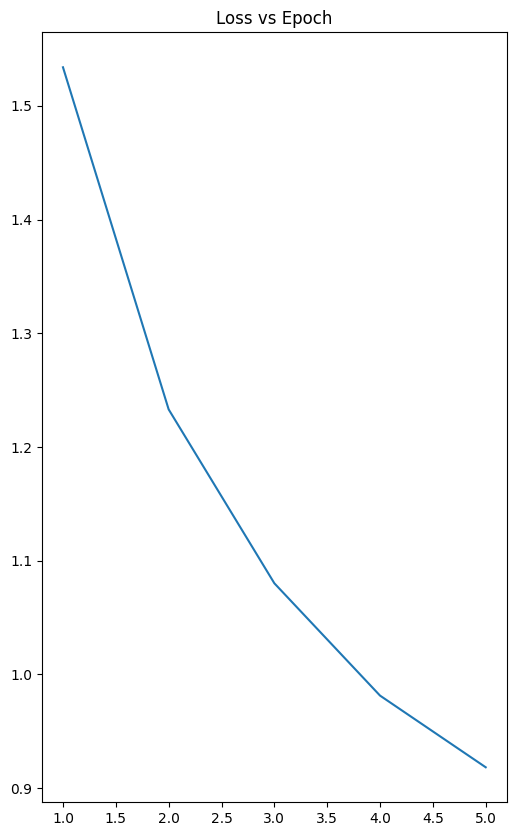

In [12]:
# reduced_dataset = Subset(bird_dataset, range(1000))
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = efficientnet_b0(weights='IMAGENET1K_V1')
model.classifier[1] = nn.Linear(model.classifier[1].in_features, NUM_CLASSES)
model.to(device)
criterion, test_loader, loss_per_epoch = train_model(model, bird_dataset, 5)

In [ ]:
original_model = efficientnet_b0(weights='IMAGENET1K_V1')
original_model.classifier[1] = nn.Linear(original_model.classifier[1].in_features, NUM_CLASSES)
original_model.to(device)
evaluate_model(original_model, criterion, test_loader)

In [ ]:
reload_model = efficientnet_b0(weights = None)
reload_model.classifier[1] = nn.Linear(reload_model.classifier[1].in_features, NUM_CLASSES)
reload_model.load_state_dict(torch.load('../models/efficientnet_b0_20260415.pth')) # after 5 epoch training
reload_model.to(device)
evaluate_model(reload_model, criterion, test_loader)

In [ ]:
print (torch.cuda.is_available())

True


In [13]:
import mlflow
print(mlflow.get_tracking_uri())

sqlite:////home/giang/Programming/AI/BirdCLEF2026/src/mlflow.db
